# 02 — Preprocessing
**Movie Recommendation System | Data Mining Midterm**

This notebook runs the full preprocessing pipeline using `src/preprocessing.py` and visualizes each step.

Steps covered:
1. Load raw data
2. Clean ratings (dedup, filter sparse users/movies, parse datetime)
3. Clean movies (extract year, encode genres)
4. Clean tags (normalize, build tag profiles)
5. Temporal train/test split
6. Build sparse user-item matrix
7. Save all artifacts


## 0. Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Add src/ to path so we can import preprocessing.py ──────────────────────
sys.path.append(os.path.abspath(".."))  # go up from notebooks/ to project root
from src.preprocessing import (
    load_ratings, load_movies, load_tags,
    clean_ratings, clean_movies, clean_tags,
    build_movie_tag_profile,
    temporal_train_test_split,
    build_user_item_matrix,
    save_processed
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (11, 4)})

# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = os.path.abspath("..")
RAW_DIR       = os.path.join(PROJECT_ROOT, "data", "raw") + os.sep
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed") + os.sep
SPLITS_DIR    = os.path.join(PROJECT_ROOT, "data", "splits") + os.sep
FIGS_DIR      = os.path.join(PROJECT_ROOT, "results", "figures") + os.sep

for d in [PROCESSED_DIR, SPLITS_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

SAMPLE = 2_000_000  # set None to use full 32M

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)

PROJECT_ROOT : d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining
RAW_DIR      : d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\raw\


## 1. Load Raw Data

In [2]:
ratings_raw = load_ratings(RAW_DIR + "ratings.csv", sample=SAMPLE)
movies_raw  = load_movies(RAW_DIR  + "movies.csv")
tags_raw    = load_tags(RAW_DIR    + "tags.csv")

display(ratings_raw.head(3))
display(movies_raw.head(3))
display(tags_raw.head(3))

[load_ratings] Loaded 2,000,000 rows
[load_movies] Loaded 87,585 movies
[load_tags] Loaded 2,000,072 tags


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469


## 2. Clean Ratings

Steps performed by `clean_ratings()`:
- Drop duplicate (userId, movieId) pairs
- Parse timestamp → datetime, year, month
- Filter users with < 20 ratings
- Filter movies with < 5 ratings


In [3]:
ratings_clean = clean_ratings(
    ratings_raw,
    min_user_ratings=20,
    min_movie_ratings=5
)
display(ratings_clean.head(3))
print(ratings_clean.dtypes)

[clean_ratings] Start: 2,000,000 rows
  After drop_duplicates   : 2,000,000
  After user filter (≥20) : 2,000,000 | users: 12,773
  After movie filter (≥5): 1,962,804 | movies: 14,297
[clean_ratings] Done: 1,962,804 rows


,userId,movieId,rating,timestamp,datetime,year,month
0,1,17,4.0,944249077,1999-12-03 19:24:37,1999,12
1,1,25,1.0,944250228,1999-12-03 19:43:48,1999,12
2,1,29,2.0,943230976,1999-11-22 00:36:16,1999,11


userId                int64
movieId               int64
rating              float64
timestamp             int64
datetime     datetime64[ns]
year                  int32
month                 int32
dtype: object


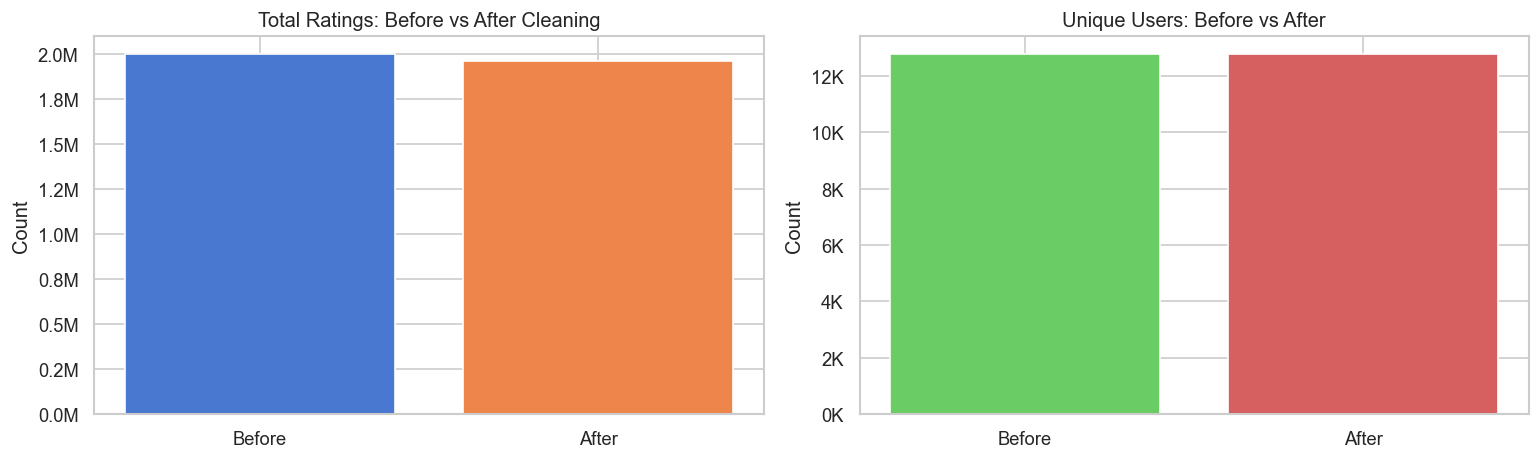

In [4]:
# Before vs After comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(["Before", "After"],
            [len(ratings_raw), len(ratings_clean)],
            color=sns.color_palette("muted")[:2])
axes[0].set_title("Total Ratings: Before vs After Cleaning")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for metric, ax in zip(["userId", "movieId"], axes[1:2]):
    pass

axes[1].bar(["Before", "After"],
            [ratings_raw["userId"].nunique(), ratings_clean["userId"].nunique()],
            color=sns.color_palette("muted")[2:4])
axes[1].set_title("Unique Users: Before vs After")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_ratings_before_after.png")
plt.show()


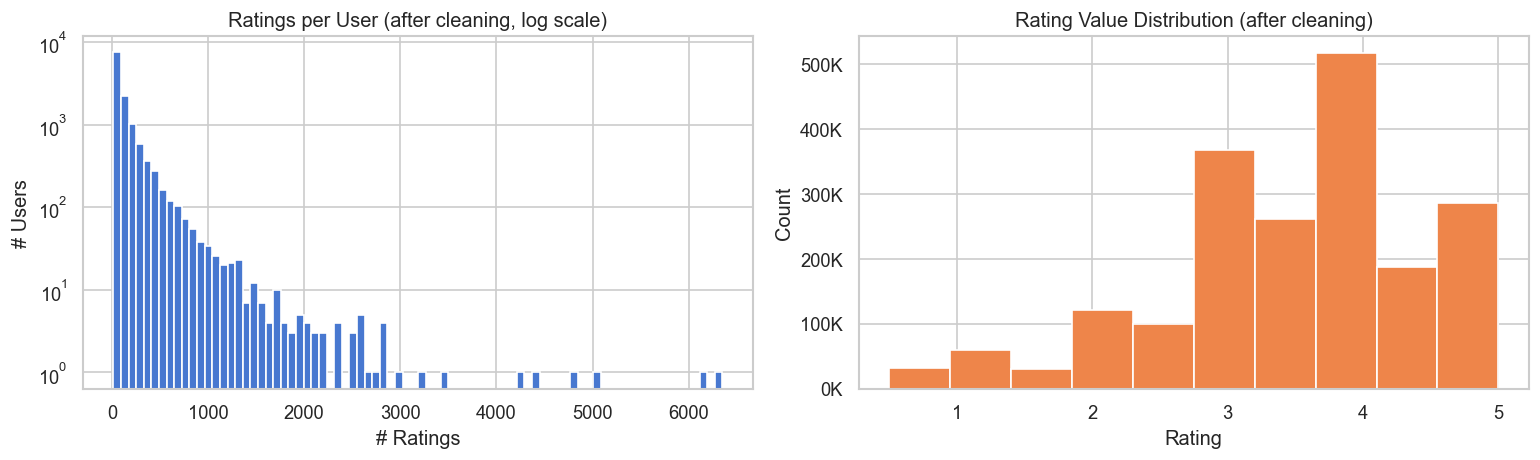

count    12773.000000
mean       153.668206
std        260.774697
min         15.000000
25%         36.000000
50%         71.000000
75%        162.000000
max       6352.000000
Name: rating, dtype: float64


In [5]:
# Ratings per user distribution (after cleaning)
rpu = ratings_clean.groupby("userId")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(rpu, bins=80, color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Ratings per User (after cleaning, log scale)")
axes[0].set_xlabel("# Ratings")
axes[0].set_ylabel("# Users")

axes[1].hist(ratings_clean["rating"], bins=10, color=sns.color_palette("muted")[1], edgecolor="white")
axes[1].set_title("Rating Value Distribution (after cleaning)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_ratings_dist.png")
plt.show()

print(rpu.describe())


## 3. Clean Movies

Steps performed by `clean_movies()`:
- Extract release year from title string
- Split pipe-separated genres into a list
- Flag movies with `(no genres listed)`
- Multi-hot encode all genres as binary columns


In [6]:
movies_clean = clean_movies(movies_raw)

# Show genre columns
genre_cols = [c for c in movies_clean.columns if c.startswith("genre_")]
print(f"Genre columns ({len(genre_cols)}):", genre_cols)
display(movies_clean[["movieId", "title", "release_year", "no_genre"] + genre_cols[:5]].head(5))

[clean_movies] Start: 87,585 movies
  Release year extracted  : 86,814 / 87,585
  No-genre movies         : 7,080
  Genres encoded          : 19
[clean_movies] Done: (87585, 25)
Genre columns (20): ['genre_list', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film_Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci_Fi', 'genre_Thriller', 'genre_War', 'genre_Western']


,movieId,title,release_year,no_genre,genre_list,genre_Action,genre_Adventure,genre_Animation,genre_Children
0,1,Toy Story (1995),1995.0,False,"[Adventure, Animation, Children, Comedy, Fantasy]",0,1,1,1
1,2,Jumanji (1995),1995.0,False,"[Adventure, Children, Fantasy]",0,1,0,1
2,3,Grumpier Old Men (1995),1995.0,False,"[Comedy, Romance]",0,0,0,0
3,4,Waiting to Exhale (1995),1995.0,False,"[Comedy, Drama, Romance]",0,0,0,0
4,5,Father of the Bride Part II (1995),1995.0,False,[Comedy],0,0,0,0


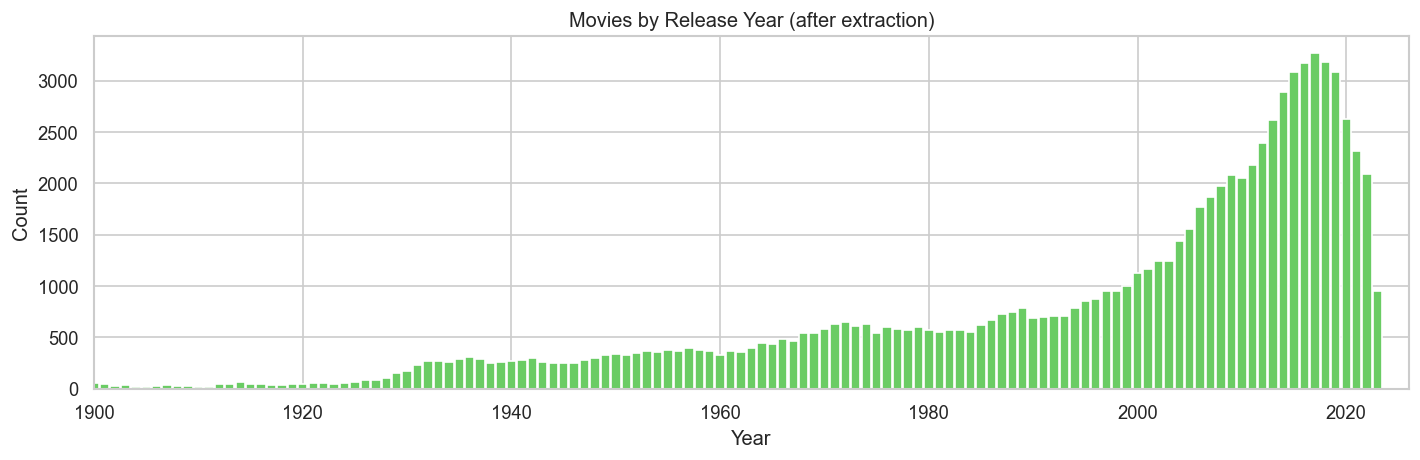

Movies missing release year: 771


In [9]:
# Release year distribution
plt.figure(figsize=(12, 4))
year_counts = movies_clean["release_year"].dropna().value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values,
        color=sns.color_palette("muted")[2], width=0.9)
plt.title("Movies by Release Year (after extraction)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xlim(1900, 2026)
plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_release_year.png")
plt.show()

missing_year = movies_clean["release_year"].isnull().sum()
print(f"Movies missing release year: {missing_year}")


## 4. Clean Tags & Build Tag Profiles

Steps performed by `clean_tags()`:
- Drop rows with null tags
- Lowercase + strip whitespace
- Drop duplicate (userId, movieId, tag) triples

Then `build_movie_tag_profile()` joins all tags per movie into one string (used for TF-IDF in content-based filtering).


In [10]:
tags_clean   = clean_tags(tags_raw)
tag_profiles = build_movie_tag_profile(tags_clean)

# Merge into movies
movies_clean = movies_clean.merge(tag_profiles, on="movieId", how="left")
movies_clean["tag_profile"] = movies_clean["tag_profile"].fillna("")

has_tags = (movies_clean["tag_profile"] != "").sum()
print(f"Movies with at least one tag : {has_tags:,} / {len(movies_clean):,}")
display(movies_clean[movies_clean["tag_profile"] != ""][["title", "tag_profile"]].head(5))


[clean_tags] Start: 2,000,072 rows
[clean_tags] Done: 2,000,040 rows
[build_movie_tag_profile] 51,323 movies have tags
Movies with at least one tag : 51,323 / 87,585


,title,tag_profile
0,Toy Story (1995),children disney animation children disney disn...
1,Jumanji (1995),robin williams fantasy robin williams time tra...
2,Grumpier Old Men (1995),comedinha de velhinhos engraãƒâ§ada comedinha ...
3,Waiting to Exhale (1995),characters slurs based on novel or book chick ...
4,Father of the Bride Part II (1995),fantasy pregnancy remake family steve martin s...


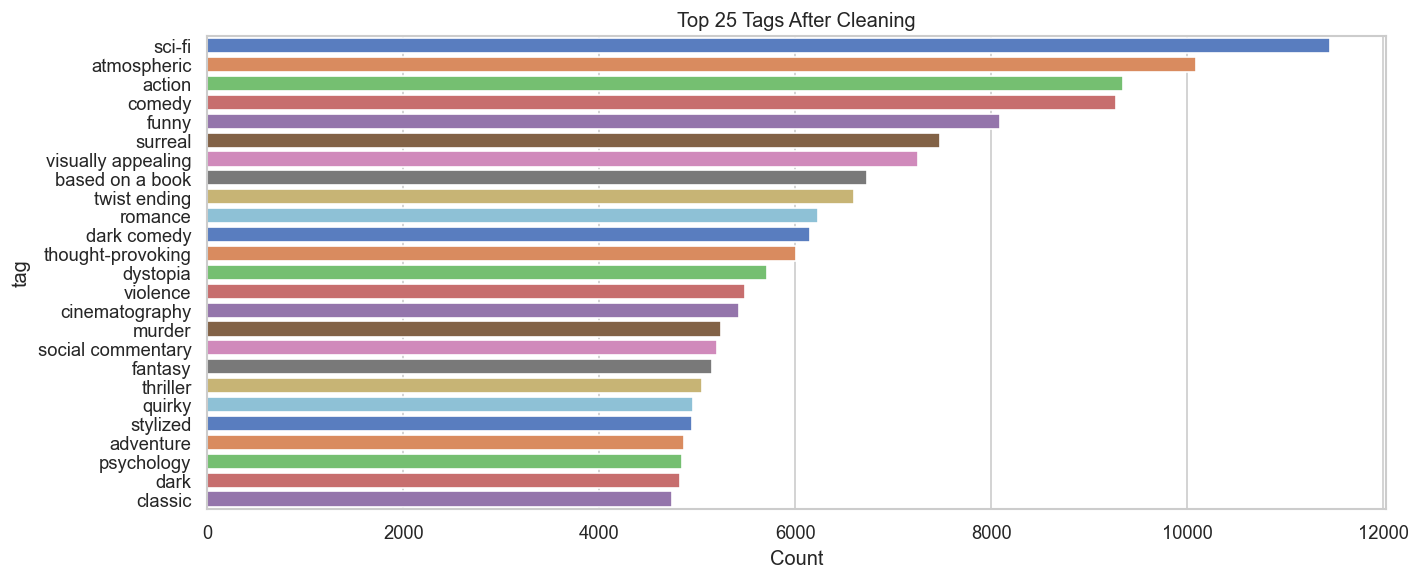

In [11]:
# Top tags after cleaning
top_tags = tags_clean["tag"].value_counts().head(25)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, palette="muted")
plt.title("Top 25 Tags After Cleaning")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_top_tags_clean.png")
plt.show()


## 5. Temporal Train / Test Split

For recommendation systems, a **temporal split is strongly preferred** over random split.  
We hold out each user's **last 20% of ratings (by time)** as the test set.

This simulates real-world deployment: the model trains on the past and predicts the future.


In [12]:
train, test = temporal_train_test_split(ratings_clean, test_ratio=0.2)

print(f"Train: {len(train):,} rows ({len(train)/len(ratings_clean):.1%})")
print(f"Test : {len(test):,} rows ({len(test)/len(ratings_clean):.1%})")


[temporal_split] Splitting 1,962,804 rows | test_ratio=0.2
  Train: 1,565,182 rows | Test: 397,622 rows
  Train users: 12,773 | Test users: 12,773
Train: 1,565,182 rows (79.7%)
Test : 397,622 rows (20.3%)


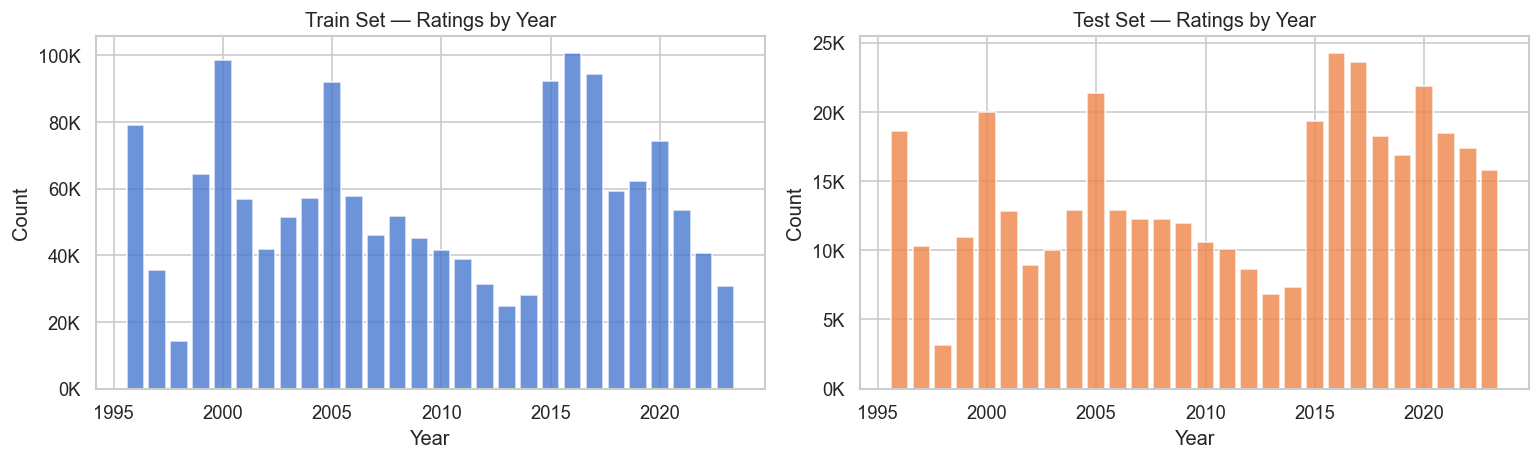

In [13]:
# Visualize time boundary per split
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, label, color in zip(
    axes,
    [train, test],
    ["Train", "Test"],
    [sns.color_palette("muted")[0], sns.color_palette("muted")[1]]
):
    year_counts = df["year"].value_counts().sort_index()
    ax.bar(year_counts.index, year_counts.values, color=color, alpha=0.8)
    ax.set_title(f"{label} Set — Ratings by Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_train_test_split.png")
plt.show()


## 6. Build User-Item Sparse Matrix

We build a `scipy.sparse.csr_matrix` from the **train set only**.  
Dense storage would require ~50 GB — sparse keeps it manageable.


In [14]:
matrix, user_to_idx, movie_to_idx = build_user_item_matrix(train)

print(f"Matrix shape   : {matrix.shape}")
print(f"Non-zero cells : {matrix.nnz:,}")
print(f"Density        : {matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.4%}")
print(f"Memory (sparse): {matrix.data.nbytes / 1e6:.1f} MB")


[build_user_item_matrix] Shape: (12773, 14246) | Density: 0.8602%
Matrix shape   : (12773, 14246)
Non-zero cells : 1,565,182
Density        : 0.8602%
Memory (sparse): 12.5 MB


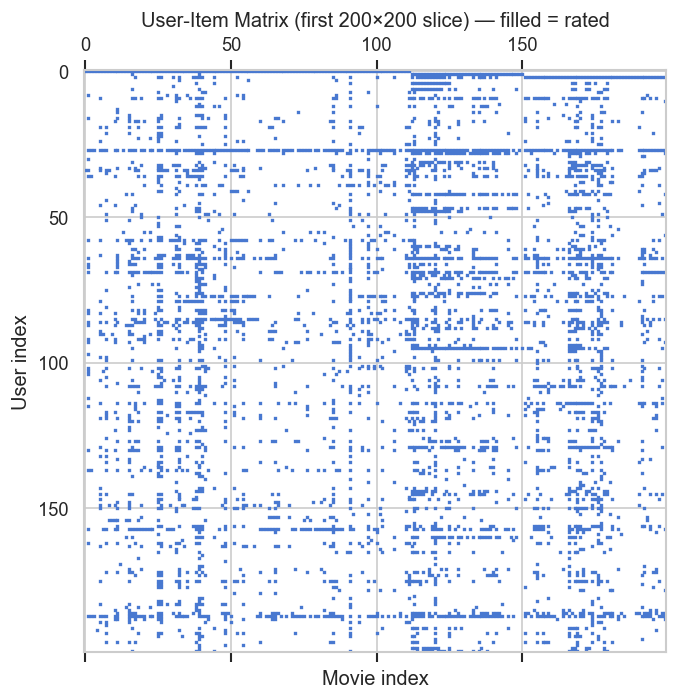

In [15]:
# Visualize a small slice of the matrix
SLICE = 200
sub = matrix[:SLICE, :SLICE].toarray()

plt.figure(figsize=(8, 6))
plt.spy(sub, markersize=1, color=sns.color_palette("muted")[0])
plt.title(f"User-Item Matrix (first {SLICE}×{SLICE} slice) — filled = rated")
plt.xlabel("Movie index")
plt.ylabel("User index")
plt.tight_layout()
plt.savefig(FIGS_DIR + "preprocessing_matrix_spy.png")
plt.show()


## 7. Save All Artifacts

In [16]:
save_processed(
    ratings_clean, movies_clean, train, test,
    matrix, user_to_idx, movie_to_idx,
    processed_dir=PROCESSED_DIR,
    splits_dir=SPLITS_DIR
)

[save_processed] All artifacts saved:
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\ratings_clean.csv
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\movies_clean.csv
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\splits\train.csv
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\splits\test.csv
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\user_item_matrix.npz
  d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\index_maps.pkl


## 8. Preprocessing Summary

| Step | Input | Output |
|---|---|---|
| clean_ratings | 2M raw ratings | Filtered, datetime-parsed ratings |
| clean_movies | 87.5K movies | + release_year, genre_list, multi-hot genres |
| clean_tags | 2M tags | Lowercased, deduped; tag_profile per movie |
| temporal_split | cleaned ratings | train.csv / test.csv (80/20 per user) |
| user_item_matrix | train ratings | Sparse CSR matrix (users × movies) |

**Saved artifacts:**
- `data/processed/ratings_clean.csv`
- `data/processed/movies_clean.csv`
- `data/splits/train.csv`
- `data/splits/test.csv`
- `data/processed/user_item_matrix.npz`
- `data/processed/index_maps.pkl`

**Next step → `03_collaborative_filtering.ipynb`**